In [3]:
data = pd.read_csv("species_data.csv")

Accuracy: 1.0
AUC Score: 1.0


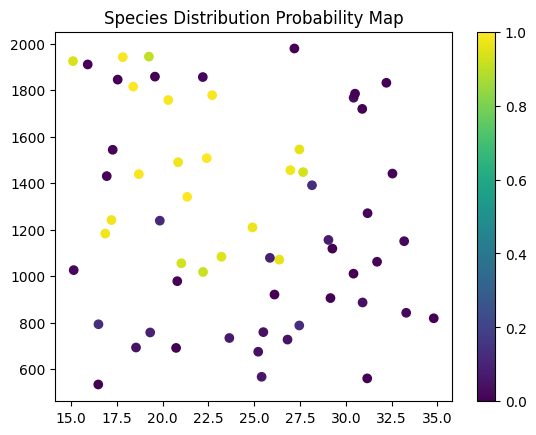

In [4]:
# ===============================================================
# Project Title: Species Distribution Probability Mapping using ML
# Description : Predicts habitat suitability for species
# Author : [Your Name]
# ===============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import joblib

# Load Data
data = pd.read_csv("species_data.csv")

# Preprocessing
X = data[['temperature', 'rainfall', 'altitude', 'vegetation']]
y = data['presence']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model Training
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print("Accuracy:", accuracy)
print("AUC Score:", auc)

# Save Model
joblib.dump(model, "species_model.pkl")

# Probability Map
prob_map = model.predict_proba(X_test)[:,1]

plt.scatter(X_test['temperature'], X_test['rainfall'], c=prob_map)
plt.colorbar()
plt.title("Species Distribution Probability Map")
plt.show()